# Preprocessing and Windowing - Daphnet FoG Dataset

**Objective:** Prepare data for FoG detection through binary label creation, 3-second sliding windows, and LOSO splits.

**Process:**
1. Load dataset
2. Create binary FoG labels
3. Generate 3-second sliding windows adapted to the dataset sampling rate (64 Hz)
4. Create LOSO splits
5. Save windowed data

## 1. Load Dataset

## 2. Create Labels

Binary labels only: 0=No FoG, 1=FoG

In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from sklearn.model_selection import LeaveOneGroupOut
import pickle

from loaders import ChariteDatasetLoader
from processing import WindowCreator, SignalCleaner

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

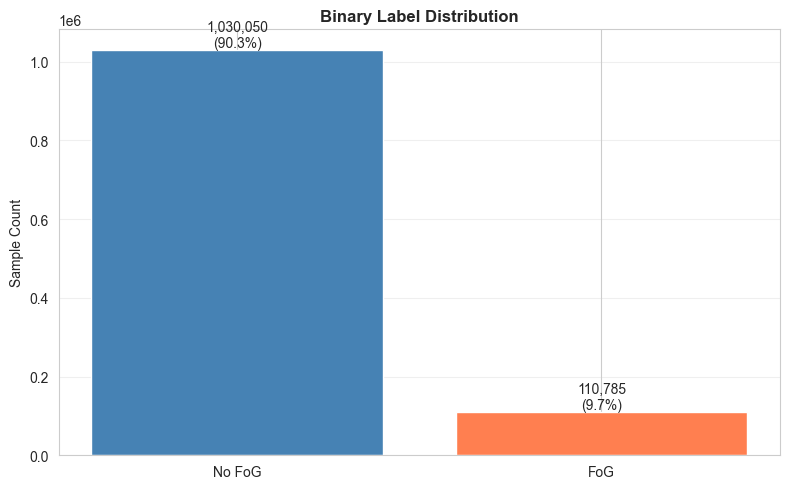

In [23]:
# Visualize binary label distribution
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

binary_counts = df['binary_label'].value_counts().sort_index()
ax.bar(['No FoG', 'FoG'], binary_counts.values, color=['steelblue', 'coral'])
ax.set_ylabel('Sample Count')
ax.set_title('Binary Label Distribution', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(binary_counts.values):
    pct = v / len(df) * 100
    ax.text(i, v, f'{v:,}\n({pct:.1f}%)', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [24]:
# Initialize window creators
# IMPROVEMENTS:
# 1. Increased train overlap from 0.5 to 0.75 → generates more FoG windows (critical with ~3-5% FoG)
# 2. Lowered min_positive_ratio from 0.30 to 0.15 → captures FoG onset/offset transitions
# 3. Kept test overlap at 0% for realistic evaluation
WINDOW_OVERLAP_TRAIN = 0.75  # 75% overlap for training (more FoG windows)
WINDOW_OVERLAP_TEST = 0.0   # 0% overlap for testing (no temporal correlation)
WINDOW_LABEL_STRATEGY = 'min_positive_ratio'
WINDOW_LABEL_MIN_POSITIVE_RATIO = 0.15  # lower threshold to capture more FoG windows

window_creator_train = WindowCreator(
    window_size=WINDOW_SIZE_SEC,
    overlap=WINDOW_OVERLAP_TRAIN,
    sampling_rate=SAMPLING_RATE,
    label_strategy=WINDOW_LABEL_STRATEGY,
    positive_labels=[1],
    min_positive_ratio=WINDOW_LABEL_MIN_POSITIVE_RATIO
)

window_creator_test = WindowCreator(
    window_size=WINDOW_SIZE_SEC,
    overlap=WINDOW_OVERLAP_TEST,
    sampling_rate=SAMPLING_RATE,
    label_strategy=WINDOW_LABEL_STRATEGY,
    positive_labels=[1],
    min_positive_ratio=WINDOW_LABEL_MIN_POSITIVE_RATIO
)

# Alias for visualization cells below
window_creator = window_creator_train

# Display configuration
config = window_creator_train.get_window_info()
print("Window Configuration:")
print(f"  Duration: {config['window_size_sec']} seconds")
print(f"  Samples: {config['window_samples']}")
print(f"  Train overlap: {WINDOW_OVERLAP_TRAIN*100:.0f}% (step: {int(config['window_samples'] * (1 - WINDOW_OVERLAP_TRAIN))} samples)")
print(f"  Test overlap:  {WINDOW_OVERLAP_TEST*100:.0f}% (no temporal correlation between test windows)")
print(f"  Label strategy: {config['label_strategy']} (threshold={config['min_positive_ratio']:.2f})")

Window Configuration:
  Duration: 3.0 seconds
  Samples: 192
  Train overlap: 75% (step: 48 samples)
  Test overlap:  0% (no temporal correlation between test windows)
  Label strategy: min_positive_ratio (threshold=0.15)


In [25]:
PREPROCESSING_CONFIG = {
    'apply_cleaning': True,
    'interpolate_outliers': True,
    'interpolate_missing': True,
    'bandpass_filter': True,       # NEW: remove gravity/DC offset and high-freq noise
    'bandpass_low_freq': 0.5,      # Hz - removes gravity component
    'bandpass_high_freq': 25.0,    # Hz - removes high-frequency noise
    'detrend_signals': True,
    'robust_normalize_per_trial': True,
    'clip_after_normalization': 8.0,
}

cleaner = SignalCleaner()

def preprocess_trial_signals(df_in, feature_cols, subject_col='subject', trial_col='trial'):
    processed_parts = []

    for (_, _), group_df in df_in.groupby([subject_col, trial_col], sort=False):
        group_df = group_df.copy()
        group_df.loc[:, feature_cols] = group_df[feature_cols].astype(float)
        values = group_df[feature_cols].replace([np.inf, -np.inf], np.nan).to_numpy(dtype=float)

        if PREPROCESSING_CONFIG['apply_cleaning']:
            values = cleaner.clean_windows(
                values[np.newaxis, :, :],
                interpolate_outliers=PREPROCESSING_CONFIG['interpolate_outliers'],
                interpolate_missing=PREPROCESSING_CONFIG['interpolate_missing']
            )[0]

        # NEW: Bandpass filter to remove gravity (DC) and high-freq noise
        # This is critical for Daphnet: raw accel includes ~1000mg gravity offset
        # which dominates features and drowns the 3-8 Hz FoG trembling signal
        if PREPROCESSING_CONFIG['bandpass_filter'] and values.shape[0] >= 30:
            values = SignalCleaner.bandpass_filter_signal(
                values,
                sampling_rate=SAMPLING_RATE,
                low_freq=PREPROCESSING_CONFIG['bandpass_low_freq'],
                high_freq=PREPROCESSING_CONFIG['bandpass_high_freq'],
                order=4
            )

        if PREPROCESSING_CONFIG['detrend_signals'] and values.shape[0] >= 3:
            values = signal.detrend(values, axis=0, type='linear')

        if PREPROCESSING_CONFIG['robust_normalize_per_trial']:
            median = np.nanmedian(values, axis=0)
            q25 = np.nanpercentile(values, 25, axis=0)
            q75 = np.nanpercentile(values, 75, axis=0)
            iqr = q75 - q25
            std = np.nanstd(values, axis=0)
            scale = np.where(iqr > 1e-6, iqr, np.where(std > 1e-6, std, 1.0))
            values = (values - median) / scale

        clip_value = PREPROCESSING_CONFIG['clip_after_normalization']
        if clip_value is not None:
            values = np.clip(values, -clip_value, clip_value)

        group_df.loc[:, feature_cols] = values
        processed_parts.append(group_df)

    return pd.concat(processed_parts, ignore_index=True)

df = preprocess_trial_signals(df, FEATURE_COLUMNS)

print('Preprocessing complete:')
for key, value in PREPROCESSING_CONFIG.items():
    print(f"  - {key}: {value}")
print(f"  Remaining NaNs in signal columns: {int(df[FEATURE_COLUMNS].isna().sum().sum())}")

AttributeError: type object 'SignalCleaner' has no attribute 'bandpass_filter_signal'

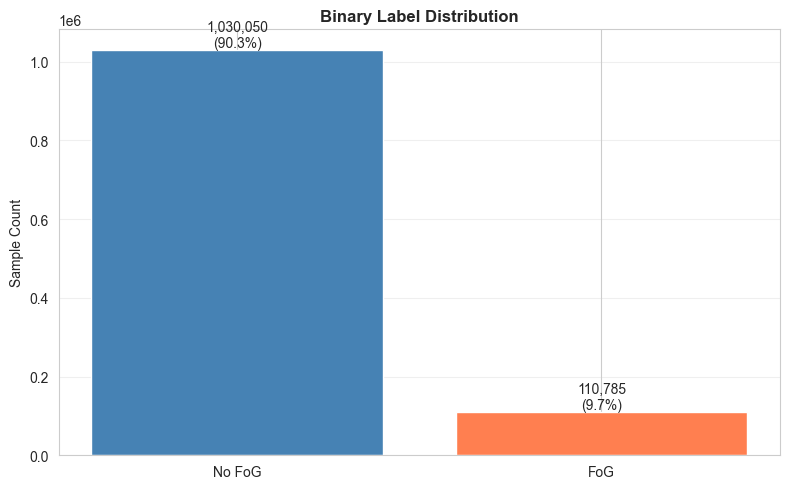

In [ ]:
# Create windows for one subject (visualization only)
print("Creating sample windows for visualization (S01)...")

subject_sample = 'S01'
df_sample = df[df['subject'] == subject_sample].reset_index(drop=True)

result_sample = window_creator_train.create_windows_from_df(
    df=df_sample,
    feature_cols=FEATURE_COLUMNS,
    binary_label_col='binary_label',
    subject_col='subject',
    trial_col='trial'
)

# Keep variable names for visualization cell below
binary_windows = result_sample['binary']['windows']
binary_labels  = result_sample['binary']['labels']

print(f"\nSample windows for {subject_sample}:")
print(f"  Shape: {binary_windows.shape}")
print(f"  Distribution: {np.bincount(binary_labels)}")
print(f"\nNote: Per-fold LOSO windows with correct train/test overlap created in Section 4.")

## 4. Create LOSO Splits

Leave-One-Subject-Out cross-validation: each subject is held out as test set once.

In [ ]:
# Visualize binary LOSO splits
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_sizes = [split['X_train'].shape[0] for split in loso_splits_binary]
test_sizes = [split['X_test'].shape[0] for split in loso_splits_binary]
test_subjects = [split['test_subject'] for split in loso_splits_binary]

x = np.arange(len(loso_splits_binary))
width = 0.35

axes[0].bar(x - width/2, train_sizes, width, label='Train', color='steelblue')
axes[0].bar(x + width/2, test_sizes, width, label='Test', color='coral')
axes[0].set_xlabel('Fold (Test Subject)')
axes[0].set_ylabel('Number of Windows')
axes[0].set_title('Binary: Train/Test Sizes', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"F{i}\n{s}" for i, s in enumerate(test_subjects)], fontsize=9)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

for i, split in enumerate(loso_splits_binary):
    dist = split['test_dist']
    axes[1].bar(i, dist[0], color='steelblue', label='No FoG' if i == 0 else '')
    axes[1].bar(i, dist[1], bottom=dist[0], color='coral', label='FoG' if i == 0 else '')

axes[1].set_xlabel('Fold (Test Subject)')
axes[1].set_ylabel('Number of Windows')
axes[1].set_title('Binary: Test Set Distribution', fontweight='bold')
axes[1].set_xticks(range(len(loso_splits_binary)))
axes[1].set_xticklabels([f"F{i}\n{s}" for i, s in enumerate(test_subjects)], fontsize=9)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Window Configuration:
  Duration: 3.0 seconds
  Samples: 192
  Train overlap: 75% (step: 48 samples)
  Test overlap:  0% (no temporal correlation between test windows)
  Label strategy: min_positive_ratio (threshold=0.15)


In [ ]:
# Summary
total_train_bin = sum([split['X_train'].shape[0] for split in loso_splits_binary])
total_test_bin  = sum([split['X_test'].shape[0]  for split in loso_splits_binary])

print("="*70)
print("PREPROCESSING SUMMARY")
print("="*70)

print(f"\nOriginal dataset:")
print(f"  Samples: {len(df):,}")
print(f"  Subjects: {df['subject'].nunique()}")

print(f"\nSignal preprocessing:")
print(f"  Cleaning applied: {PREPROCESSING_CONFIG['apply_cleaning']}")
print(f"  Detrending: {PREPROCESSING_CONFIG['detrend_signals']}")
print(f"  Robust normalization per trial: {PREPROCESSING_CONFIG['robust_normalize_per_trial']}")
print(f"  Clipping after normalization: ±{PREPROCESSING_CONFIG['clip_after_normalization']}")

print(f"\nWindow creation strategy:")
print(f"  Configuration: {WINDOW_SIZE_SEC}s")
print(f"  Train overlap: {WINDOW_OVERLAP_TRAIN*100:.0f}% (step: {int(WINDOW_SIZE_SEC * SAMPLING_RATE * (1 - WINDOW_OVERLAP_TRAIN))} samples)")
print(f"  Test overlap:  {WINDOW_OVERLAP_TEST*100:.0f}% (no temporal correlation between test windows)")
print(f"  Label threshold: {WINDOW_LABEL_MIN_POSITIVE_RATIO:.2f} positive ratio")
print(f"  Window shape: ({config['window_samples']} samples, {len(FEATURE_COLUMNS)} features)")

print(f"\nLOSO splits:")
print(f"  Folds: {len(loso_splits_binary)}")
print(f"  Avg train windows/fold: {total_train_bin/len(loso_splits_binary):.0f}")
print(f"  Avg test windows/fold:  {total_test_bin/len(loso_splits_binary):.0f}")
print(f"  Total unique test windows: {total_test_bin:,}")

all_test_y = np.concatenate([split['y_test'] for split in loso_splits_binary])
print(f"\nClass balance (aggregated test windows, binary):")
print(f"  No FoG: {np.sum(all_test_y == 0):,} ({np.sum(all_test_y == 0)/len(all_test_y)*100:.1f}%)")
print(f"  FoG:    {np.sum(all_test_y == 1):,} ({np.sum(all_test_y == 1)/len(all_test_y)*100:.1f}%)")
print("="*70)

PREPROCESSING SUMMARY

Original dataset:
  Samples: 1,140,835
  Subjects: 10

Window creation strategy:
  Configuration: 2.0s
  Train overlap: 50% (step: 64 samples)
  Test overlap:  0% (no temporal correlation between test windows)
  Window shape: (128 samples, 9 features)

LOSO splits:
  Folds: 10
  Avg train windows/fold: 16027
  Avg test windows/fold:  891
  Total unique test windows: 8,912

Class balance (aggregated test windows, binary):
  No FoG: 7,843 (88.0%)
  FoG:    1,069 (12.0%)


In [ ]:
# Create output directory
output_dir = Path('../../outputs/datasets_csv')
output_dir.mkdir(parents=True, exist_ok=True)

# Save labeled dataset
csv_path = output_dir / 'daphnet_segmented_dataset.csv'
df.to_csv(csv_path, index=False)
print(f"Labeled dataset saved: {csv_path}")
print(f"  Samples: {len(df):,}")
print(f"  Columns: {len(df.columns)}")

# Save binary LOSO splits
binary_path = output_dir / 'daphnet_loso_windows_binary.pkl'
with open(binary_path, 'wb') as f:
    pickle.dump(loso_splits_binary, f)
print(f"\nBinary LOSO splits saved: {binary_path}")
print(f"  Folds: {len(loso_splits_binary)}")
print(f"  Total windows: {sum([len(s['y_train']) + len(s['y_test']) for s in loso_splits_binary]):,}")

print("\n" + "="*70)
print("All data saved successfully.")
print("="*70)

Labeled dataset saved: ..\..\outputs\datasets_csv\daphnet_segmented_dataset.csv
  Samples: 1,140,835
  Columns: 19

Binary LOSO splits saved: ..\..\outputs\datasets_csv\daphnet_loso_windows_binary.pkl
  Folds: 10
  Total windows: 112,677

All data saved successfully.


AttributeError: type object 'SignalCleaner' has no attribute 'bandpass_filter_signal'